# Ethylene excited state ePS results: AF calcs
26/03/25

- Ethylene excited states as below.
- For AF case, set some arb distributions (not sure of exact values).


20/03/25

- 2nd test, with channels:
    - orb7 > 10 > D1 (pi-pi*)
    - orb8 > 10 > D0 (sigma-pi*)
    - DATADIR: `/home/jovyan/jake-home/ePS/ethylene_2025/ethylene_sig-pi`

- 1st tests for excited states, 1st excited state only (orb9), no alignment.
    - Seems to be some issues with files, maybe low(est) E point(s)...?
    - Allow for SF = NaN case.
    - Need to check for case where Eke won't stack.
    - TODO: debug routine to check file IO more carefully. Currently a total mess to try and debug via classes.
    - FILE: `ethylene_es_MF_proc_ePSproc_200325-v1-es-dir.ipynb`, 
    - DATADIR: `/home/jovyan/jake-home/ePS/ethylene_2025/ethylene_es` first set of excited states (named by ionizing orb only).
    

---

For methods: https://epsproc.readthedocs.io/en/dev/demos/ePSproc_class_demo_161020.html

Most recent ePSproc template: https://phockett.github.io/ePSdata/CO2-preliminary/CO2_orbs8-11_MF_polRotDep_220824-tidy-v290125.html

## Setup

In [1]:
%matplotlib inline

# Quick hack to override default HTML template
# NOT required in some JLab versions.
# https://stackoverflow.com/a/63777508
# https://stackoverflow.com/questions/21971449/how-do-i-increase-the-cell-width-of-the-jupyter-ipython-notebook-in-my-browser
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))



/tmp/ipykernel_112186/843188395.py:7: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [2]:
import sys
import os
from pathlib import Path
import numpy as np
# import epsproc as ep
import xarray as xr

import matplotlib.pyplot as plt

from datetime import datetime as dt
timeString = dt.now()

import epsproc as ep

# Plotters
from epsproc.plot import hvPlotters

# Multijob class dev code
from epsproc.classes.multiJob import ePSmultiJob

hvPlotters.setPlotters(width = 700, snsStyle='whitegrid')

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


* sparse not found, sparse matrix forms not available. 
* natsort not found, some sorting functions not available. 


* Setting plotter defaults with epsproc.basicPlotters.setPlotters(). Run directly to modify, or change options in local env.


* Set Holoviews with bokeh.
* pyevtk not found, VTK export not available. 


* Set Holoviews with bokeh.


In [3]:
# # For class, above settings don't take, not sure why, something to do with namespaces/calling sequence?
# # Overriding snsStyle does work however... although NOT CONSISTENTLY????
# # AH, looks like ordering matters - set_style LAST (.set seems to override)
# import seaborn as sns

# sns.set(rc={'figure.figsize':(10,6)})  # Set figure size in inches
# sns.set_context("paper")
# sns.set_style("whitegrid")  # Set plot style
# sns.set_palette("Paired")   # Set colour mapping

# # Try direct fig type setting for PDF output figs
# from IPython.display import set_matplotlib_formats
# # set_matplotlib_formats('png', 'pdf')
# set_matplotlib_formats('svg', 'pdf')

In [4]:
# xr.set_options(display_style='html')

## Load data

In [5]:
# import warnings
# # warnings.filterwarnings('once')   # Skip repeated numpy deprecation warnings in current build (xr15 env)
# warnings.filterwarnings('ignore')   # Skip repeated numpy deprecation warnings in current build (xr15 env)

In [6]:
# # Scan for subdirs, based on existing routine in getFiles()

# fileBase = Path('/home/paul/ePS/OCS/OCS_survey')  # Data dir on Stimpy

# fileBase = Path('/home/paul/fock-mount/globalhome/eps/N2O/N2O_valence') # Data dir on Jake

# fileBase = Path('/home/jovyan/jake-home/femtobackSSHFS/FemtoShare/Results/ePolyScat_stuff/co2') # Data dir on Jake via Docker QM3 container

# fileBase = Path('/home/jovyan/fock-mount/globalhome/eps/ethylene_2025/ethylene_valence/orb9_AG/completed') # Data dir on Jake - test results only
# fileBase = Path('/home/jovyan/jake-home/ePS/ethylene_2025/ethylene_es')  # Initial ES runs, March 2025
fileBase = Path('/home/jovyan/jake-home/ePS/ethylene_2025/ethylene_sig-pi')  # orb7, orb8 excitations, 26/03/25

In [7]:
ep.__file__

'/home/jovyan/code-share/github-share/ePSproc/epsproc/__init__.py'

In [8]:
# TODO: fix orb label here, currently relies on (different) fixed format

data = ePSmultiJob(fileBase, verbose = 1, ext='.out', jobStructure='subDirs')  # TODO: fix subDirs usage!
                                                                                    # CO2 case: fix by setting .inp.out, otherwise also reads base dir (older results)

# data.scanFiles(outputKeyType='orb')  #, stackE = False)   # For ethylene 1st excited state seems to read OK with stackE=False? Not sure why... NEED SOME FILE CHECK/DEBUG CODE?
data.scanFiles(outputKeyType='dir')  #, stackE = False)
# data.jobsSummary()

Scanning /home/jovyan/jake-home/ePS/ethylene_2025/ethylene_sig-pi for ePS jobs.
Found ePS output files in subdirs: [PosixPath('/home/jovyan/jake-home/ePS/ethylene_2025/ethylene_sig-pi/orb8-orb10_B1U'), PosixPath('/home/jovyan/jake-home/ePS/ethylene_2025/ethylene_sig-pi/orb7-orb10_B1U')]
Found 2 directories, with 8 files.

*** Job orb8-orb10_B1U details
Key: orb8-orb10_B1U
Dir /home/jovyan/jake-home/ePS/ethylene_2025/ethylene_sig-pi/orb8-orb10_B1U, 4 file(s).
{   'batch': 'ePS ethylene_2025, batch ethylene_valence, orbital orb10_B1U',
    'event': 'orb 10 (B1U/D2h) ionization, batch ethylene_valence, None.',
    'orbE': 1.3687327281731962,
    'orbLabel': 'orb8-orb10_B1U',
    'symmetryLabel': 'B1U/D2h'}

*** Job orb7-orb10_B1U details
Key: orb7-orb10_B1U
Dir /home/jovyan/jake-home/ePS/ethylene_2025/ethylene_sig-pi/orb7-orb10_B1U, 4 file(s).
{   'batch': 'ePS ethylene_2025, batch ethylene_es, orbital orb10_B1U',
    'event': 'orb 10 (B1U/D2h) ionization, batch ethylene_es, None.',
    '

In [9]:
data.data.keys()

dict_keys(['orb8-orb10_B1U', 'orb7-orb10_B1U', 'stacked'])

In [10]:
data.jobs

{'fileBase': PosixPath('/home/jovyan/jake-home/ePS/ethylene_2025/ethylene_sig-pi'),
 'ext': '.out',
 'prefix': None,
 'jobDirs': [PosixPath('/home/jovyan/jake-home/ePS/ethylene_2025/ethylene_sig-pi/orb8-orb10_B1U'),
  PosixPath('/home/jovyan/jake-home/ePS/ethylene_2025/ethylene_sig-pi/orb7-orb10_B1U')],
 'jobStructure': 'subDirs',
 'files': {0: {'dir': PosixPath('/home/jovyan/jake-home/ePS/ethylene_2025/ethylene_sig-pi/orb8-orb10_B1U'),
   'fN': 4,
   'key': 'orb8-orb10_B1U',
   'fileList': ['/home/jovyan/jake-home/ePS/ethylene_2025/ethylene_sig-pi/orb8-orb10_B1U/ethylene_valence.orb10_B1U_E0.1_4.0_48.1eV.out',
    '/home/jovyan/jake-home/ePS/ethylene_2025/ethylene_sig-pi/orb8-orb10_B1U/ethylene_valence.orb10_B1U_E1.1_4.0_49.1eV.out',
    '/home/jovyan/jake-home/ePS/ethylene_2025/ethylene_sig-pi/orb8-orb10_B1U/ethylene_valence.orb10_B1U_E2.1_4.0_50.1eV.out',
    '/home/jovyan/jake-home/ePS/ethylene_2025/ethylene_sig-pi/orb8-orb10_B1U/ethylene_valence.orb10_B1U_E3.1_4.0_51.1eV.out']},
 

## Molecule info

Note orbital numbering in table below:

- `Orb` is Gamess file output orbital numbering, ordered by energy but not grouped by degeneracy.
- `OrbGrp` is grouped numbering by degeneracy, also used by ePolyScat, and will be used for labels etc. below.

For ethylene case channels were defined as:

- orb7 > 10 > D1 (pi-pi*)
- orb8 > 10 > D0 (sigma-pi*)

In both cases the initial state has an e- in Orb10 (promoted from Orb7 or Orb8), which is then ionized.

*** Molecular structure


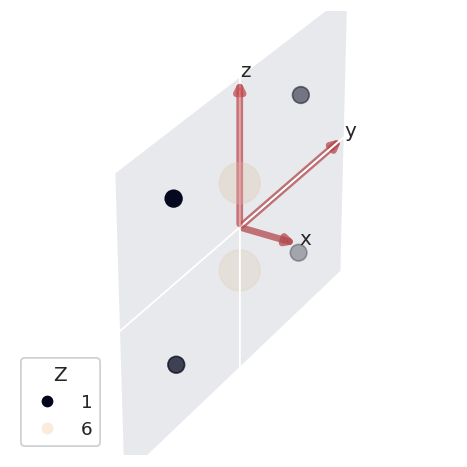


*** Molecular orbital list (from ePS output file)
EH = Energy (Hartrees), E = Energy (eV), NOrbGrp, OrbGrp, GrpDegen = degeneracies and corresponding orbital numbering by group in ePS, NormInt = single centre expansion convergence (should be ~1.0).


props,Sym,SymOrb,EH,Occ,E,NOrbGrp,OrbGrp,GrpDegen,NormInt
orb,,,,,,,,,
1,AG,0.0,-11.2385,2.0,-305.815164,1.0,1.0,1.0,0.999386
2,B1U,0.0,-11.2367,2.0,-305.766184,1.0,2.0,1.0,0.999386
3,AG,0.0,-1.0395,2.0,-28.286236,1.0,3.0,1.0,0.999386
4,B1U,0.0,-0.7933,2.0,-21.586793,1.0,4.0,1.0,0.999386
5,B2U,0.0,-0.6450,2.0,-17.551344,1.0,5.0,1.0,0.999386
6,AG,0.0,-0.5904,2.0,-16.065602,1.0,6.0,1.0,0.999386
7,B3G,0.0,-0.5055,2.0,-13.755356,1.0,7.0,1.0,0.999386
8,B3U,0.0,-0.3793,2.0,-10.321279,1.0,8.0,1.0,0.999386
9,AG,0.0,0.0404,0.0,1.099340,1.0,9.0,1.0,0.999386


In [11]:
data.molSummary()

## Define AF

For general behaviour, just set this to run from $A20 = -0.5$ (\~sin^2 dist) to $A20 = +1$ (\~cos^2 dist).

In [21]:
tpoints = 10
ADM = ep.setADMs([np.ones(tpoints),np.linspace(-0.5,1,tpoints)], KQSLabels=[[0,0,0],[2,0,0]])

# Set to main data structure for calcs
data.data['ADM'] = {'ADM':ADM}

data.ADMplot(keys='ADM')

<xarray.DataArray 'ADM' (ADM: 2, t: 10)>
array([[ 1.        ,  1.        ,  1.        ,  1.        ,  1.        ,
         1.        ,  1.        ,  1.        ,  1.        ,  1.        ],
       [-0.5       , -0.33333333, -0.16666667,  0.        ,  0.16666667,
         0.33333333,  0.5       ,  0.66666667,  0.83333333,  1.        ]])
Coordinates:
  * ADM      (ADM) MultiIndex
  - K        (ADM) int64 0 2
  - Q        (ADM) int64 0 0
  - S        (ADM) int64 0 0
  * t        (t) int64 0 1 2 3 4 5 6 7 8 9
Attributes:
    dataType:   ADM
    long_name:  Axis distribution moments
    units:      arb

## Compute AF results

In [26]:
thres = 1e-2
data.AFBLM(AKQS = ADM, selDims = {'Type':'L'}, thres=thres) 


Calculating AF-BLMs for job key: orb7-orb10_B1U

Calculating AF-BLMs for job key: orb8-orb10_B1U


### AF plots

Note interactive plots.

For the heatmap, use the "box select" tool on the histogram to change the cmapping range (required for B4 values).

Main thing of note from the heatmaps is:

- not much change in B2 with alignment, 
- some sign changes in B4.

Note beta params are spherical harmonic normalised here.

In [42]:
data.BLMplot(backend='hv', xDim = 't', hvType='heatmap', addHist = True, addADMs = True, 
             clim=(-0.5,1), cmap='vlag', width=1000, frame_width=860, filterXS=1e-4)   #, selDims={'l':2})

BLMplot set data and plots to self.plots['BLMplot']


:Layout
   .AdjointLayout.I :AdjointLayout
      :HoloMap   [Orb,l,m]
         :HeatMap   [t,Eke]   (BLM)
      :HoloMap   [Orb,l,m]
         :Histogram   [BLM]   (BLM_count)
   .NdOverlay.I     :NdOverlay   [K]
      :Curve   [t]   (ADM)

True

In [49]:
# Line-outs - Eke per (orb,t)
# Note this is quite slow to render
data.BLMplot(backend='hv', hvType='line', xDim = 'Eke', ylim=(-1,2), filterXS=1e-3, addADMs = False, height=800, width=1000)



BLMplot set data and plots to self.plots['BLMplot']


:HoloMap   [Orb,t]
   :NdOverlay   [l,m]
      :Curve   [Eke]   (BLM)

True

## Versions

In [43]:
# print(data.jobInfo['ePolyScat'][0])
# print('Run: ' + jobInfo['Starting'][0].split('at')[1])

In [44]:
import scooby
scooby.Report(additional=['epsproc', 'xarray', 'jupyter'])

--------------------------------------------------------------------------------
  Date: Wed Mar 26 14:18:07 2025 EDT

                OS : Linux
            CPU(s) : 64
           Machine : x86_64
      Architecture : 64bit
               RAM : 62.8 GiB
       Environment : Jupyter
       File system : btrfs

  Python 3.10.11 | packaged by conda-forge | (main, May 10 2023, 18:58:44)
  [GCC 11.3.0]

           epsproc : 1.3.2-dev
            xarray : 2022.3.0
           jupyter : Version unknown
             numpy : 1.23.5
             scipy : 1.10.1
           IPython : 8.13.2
        matplotlib : 3.5.3
            scooby : 0.7.2
--------------------------------------------------------------------------------

In [45]:
# Check current Git commit for local ePSproc version
!git -C {Path(ep.__file__).parent} branch
!git -C {Path(ep.__file__).parent} log --format="%H" -n 1

* 3d-AFPAD-dev
  dev
  master
56c01f0a1f3ba90c1409a32a276c241e04165638


In [46]:
# Check current remote commits
!git ls-remote --heads https://github.com/phockett/ePSproc

56c01f0a1f3ba90c1409a32a276c241e04165638	refs/heads/3d-AFPAD-dev
ff437df39999292cefaa659749067b063db68ce8	refs/heads/dependabot/pip/notes/envs/envs-versioned/ipython-8.10.0
840c9a0fdbd9b1a66f5a0275ea7fa6db2193c8a6	refs/heads/dependabot/pip/notes/envs/envs-versioned/jinja2-3.1.5
0e5e04353d0fbf2da5b5de120a1e87d03de865dd	refs/heads/dependabot/pip/notes/envs/envs-versioned/tornado-6.4.2
a00ba1c9e762c85bdae2de68d4b93214ddee9063	refs/heads/dependabot/pip/notes/envs/envs-versioned/wheel-0.38.1
7e4270370d66df44c334675ac487c87d702408da	refs/heads/dev
1c0b8fd409648f07c85f4f20628b5ea7627e0c4e	refs/heads/master
69cd89ce5bc0ad6d465a4bd8df6fba15d3fd1aee	refs/heads/numba-tests
ea30878c842f09d525fbf39fa269fa2302a13b57	refs/heads/revert-9-master
baf0be0c962e8ab3c3df57c8f70f0e939f99cbd7	refs/heads/testDev


## Env

In [47]:
!hostname

8fdb9101787f


In [48]:
!conda env list

# conda environments:
#
base                  *  /opt/conda

